# **Case QuantumFinance - Natural Language Processing - Classificador de chamados**

**Atenção:**
- Leia com atenção o descritivo do trabalho e as orientações do template.
- O trabalho deve ser entregue respeitando a estrutura do arquivo de template em notebook "Template_Trabalho_Final_NLP.ipynb" e compactado no formato .zip. Apenas um arquivo no formato .ipynb deve ser entregue consolidando todo o trabalho.

###**Crie um classificador de chamados aplicando técnicas de PLN**
---

A **QuantumFinance** tem um canal de atendimento via chat e precisar classificar os assuntos dos atendimentos para melhorar as tratativas dos chamados dos clientes. O canal recebe textos abertos dos clientes relatando o problema e/ou dúvida e depois é direcionado para alguma área especialista no assunto para uma melhor tratativa.​

1. Crie ao menos um modelo classificador de assuntos aplicando técnicas de NLP (PLN), Vetorização (n-grama + métrica) e modelo supervisionado, que consiga classificar através de um texto o assunto conforme disponível na base de dados [1] para treinamento e validação do seu modelo.​

  O modelo precisar atingir um score na **métrica F1 Score superior a 75%**. Utilize o dataset [1] para treinar e testar o modelo, separe o dataset em duas amostras (75% para treinamento e 25% para teste com o randon_state igual a 42).​

2. Utilizar ao menos uma aplicação de modelos com Embeddings usando Word2Vec e/ou LLM´s para criar o modelo classificador com os critérios do item 1.

Fique à vontade para testar e explorar as técnicas de pré-processamento, abordagens de NLP, algoritmos e bibliotecas, mas explique e justifique as suas decisões durante o desenvolvimento.​

**Composição da nota:​**

**50%** - Demonstrações das aplicações das técnicas de PLN (regras, pré-processamentos, tratamentos, variedade de modelos aplicados, aplicações de Embeddings, organização do pipeline, etc.)​

**50%** - Baseado na performance (score) obtida com a amostra de teste no pipeline do modelo campeão (validar com  a Métrica F1 Score). **Separar o pipeline completo do modelo campeão conforme template.​**

O trabalho poderá ser feito em grupo de 2 até 4 pessoas (mesmo grupo do Startup One) e trabalhos iguais serão descontado nota e passível de reprovação.

**[1] = ​https://dados-ml-pln.s3.sa-east-1.amazonaws.com/tickets_reclamacoes_classificados.csv**

**[F1 Score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html)** com average='weighted'

In [ ]:
# CARREGANDO O DATA FRAME
import pandas as pd
df = pd.read_csv('https://dados-ml-pln.s3.sa-east-1.amazonaws.com/tickets_reclamacoes_classificados.csv', delimiter=';')

# Façam o download do arquivo e utilizem localmente durante os testes

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21072 entries, 0 to 21071
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id_reclamacao         21072 non-null  int64 
 1   data_abertura         21072 non-null  object
 2   categoria             21072 non-null  object
 3   descricao_reclamacao  21072 non-null  object
dtypes: int64(1), object(3)
memory usage: 658.6+ KB


Bom desenvolvimento!

###**Area de desenvolvimento e validações**

Faça aqui as demonstrações das aplicações das técnicas de PLN (regras, pré-processamentos, tratamentos, variedade de modelos aplicados, organização do pipeline, etc.)​

Fique à vontade para testar e explorar as técnicas de pré-processamento, abordagens de NLP, algoritmos e bibliotecas, mas explique e justifique as suas decisões durante o desenvolvimento.​

In [ ]:
# =========================
# 1) Setup + Visão inicial
# =========================
import re
import unicodedata
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

import matplotlib.pyplot as plt

# Conferindo colunas (ajuste se seu dataset vier com nomes diferentes)
df.head()


,id_reclamacao,data_abertura,categoria,descricao_reclamacao
0,3229299,2019-05-01T12:00:00-05:00,Hipotecas / Empréstimos,"Bom dia, meu nome é xxxx xxxx e agradeço se vo..."
1,3199379,2019-04-02T12:00:00-05:00,Cartão de crédito / Cartão pré-pago,Atualizei meu cartão xxxx xxxx em xx/xx/2018 e...
2,3233499,2019-05-06T12:00:00-05:00,Cartão de crédito / Cartão pré-pago,O cartão Chase foi relatado em xx/xx/2019. No ...
3,3180294,2019-03-14T12:00:00-05:00,Cartão de crédito / Cartão pré-pago,"Em xx/xx/2018, enquanto tentava reservar um ti..."
4,3224980,2019-04-27T12:00:00-05:00,Serviços de conta bancária,"Meu neto me dê cheque por {$ 1600,00} Eu depos..."


Shape: (21072, 4)


,id_reclamacao,data_abertura,categoria,descricao_reclamacao
10796,2505290,2017-06-08T12:00:00-05:00,Serviços de conta bancária,Oxxxx xxxx pagou o JP Morgan Chase {$ 1200.00}...
16441,3625355,2020-04-27T12:00:00-05:00,Roubo / Relatório de disputa,Perdi meu cartão de crédito (uma reserva de sa...
16623,1405636,2015-06-04T12:00:00-05:00,Hipotecas / Empréstimos,"Em 2005, fui para xxxx xxxx xxxx. Eles me dire..."
12833,2915672,2018-05-23T12:00:00-05:00,Roubo / Relatório de disputa,Eu me inscrevi e recebi um cartão de crédito p...
14844,1733697,2016-01-08T12:00:00-05:00,Roubo / Relatório de disputa,"Com o Chase A {$ 620,00} Charge (xxxx 2015) fo..."



Colunas: ['id_reclamacao', 'data_abertura', 'categoria', 'descricao_reclamacao']
Usando text_col='id_reclamacao' | label_col='categoria'

Nulos por coluna:


,0
id_reclamacao,0
categoria,0


,count
categoria,
Serviços de conta bancária,5161
Cartão de crédito / Cartão pré-pago,5006
Roubo / Relatório de disputa,4822
Hipotecas / Empréstimos,3850
Outros,2233


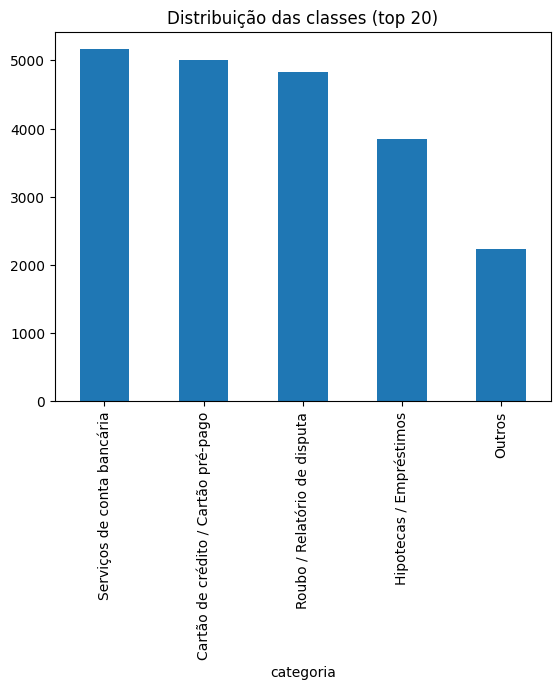


Resumo tamanho do texto:


,id_reclamacao
count,21072.0
mean,7.0
std,0.0
min,7.0
25%,7.0
50%,7.0
75%,7.0
max,7.0


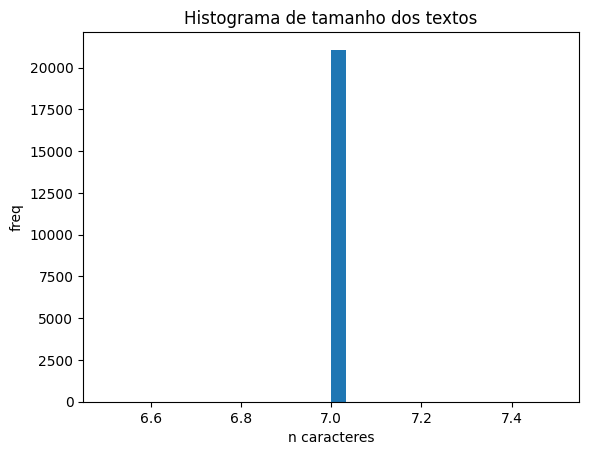

In [ ]:
# ===========================================
# 2) Entendimento da base (EDA rápida e útil)
# ===========================================
print("Shape:", df.shape)
display(df.sample(5, random_state=42))

# Tentando inferir nomes de colunas (texto e label)
# Esperado: uma coluna com o texto do chamado e uma coluna com o assunto/classificação.
print("\nColunas:", df.columns.tolist())

# Heurística: procurar colunas comuns em datasets de tickets
possible_text_cols = [c for c in df.columns if c.lower() in ["texto", "text", "mensagem", "mensagem_cliente", "descricao", "descrição", "chamado", "reclamacao", "reclamação", "ticket", "conteudo", "conteúdo"]]
possible_label_cols = [c for c in df.columns if c.lower() in ["assunto", "classe", "class", "categoria", "category", "rotulo", "rótulo", "label", "classificacao", "classificação"]]

text_col = possible_text_cols[0] if possible_text_cols else df.columns[0]
label_col = possible_label_cols[0] if possible_label_cols else df.columns[1]

print(f"Usando text_col='{text_col}' | label_col='{label_col}'")

# Nulos
print("\nNulos por coluna:")
display(df[[text_col, label_col]].isna().sum())

# Distribuição das classes
dist = df[label_col].value_counts()
display(dist.head(20))

plt.figure()
dist.plot(kind="bar")
plt.title("Distribuição das classes (top 20)")
plt.show()

# Tamanho dos textos
lens = df[text_col].astype(str).str.len()
print("\nResumo tamanho do texto:")
display(lens.describe())

plt.figure()
plt.hist(lens, bins=30)
plt.title("Histograma de tamanho dos textos")
plt.xlabel("n caracteres")
plt.ylabel("freq")
plt.show()


In [ ]:
# ==========================================================
# 3) Pré-processamento (decisões e justificativas)
# ==========================================================
# Objetivo: reduzir ruído e padronizar o texto mantendo informação semântica útil.
# - lower(): reduz sparsidade
# - remoção de acentos: reduz variantes ("cartão" vs "cartao")
# - remoção de caracteres não alfabéticos (mantendo espaço): reduz ruído
# Obs.: para TF-IDF, frequentemente *não* é necessário lematizar; o próprio modelo lida bem
# com variações por n-gramas. Vamos testar com e sem normalização.

def strip_accents(s: str) -> str:
    return "".join(
        ch for ch in unicodedata.normalize("NFKD", s)
        if not unicodedata.combining(ch)
    )

def normalize_text(s: str) -> str:
    s = str(s).lower()
    s = strip_accents(s)
    s = re.sub(r"\S+@\S+", " ", s)             # e-mails
    s = re.sub(r"http\S+|www\.\S+", " ", s)   # urls
    s = re.sub(r"\d+", " ", s)                  # números
    s = re.sub(r"[^a-z\s]", " ", s)             # pontuação / símbolos
    s = re.sub(r"\s+", " ", s).strip()
    return s

# Conferindo efeito do pré-processamento
ex = df[text_col].iloc[0]
print("ORIGINAL:\n", ex)
print("\nNORMALIZADO:\n", normalize_text(ex))


ORIGINAL:
 3229299

NORMALIZADO:
 


In [ ]:
# ==========================================================
# 4) Split treino/teste + Modelos (TF-IDF / n-gramas)
# ==========================================================

# Fix: Explicitly set text_col and label_col to use the correct columns
text_col = 'descricao_reclamacao'
label_col = 'categoria'

X = df[text_col].astype(str)
y = df[label_col].astype(str)

# Separação conforme requisito: 75% treino, 25% teste, random_state=42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Treino:", X_train.shape, "Teste:", X_test.shape)

# Baseline: "chuta" sempre a classe mais frequente
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train, y_train)
pred_dummy = dummy.predict(X_test)
print("Dummy F1 (weighted):", f1_score(y_test, pred_dummy, average="weighted"))

# Pipeline 1: TF-IDF + Naive Bayes (rápido, bom ponto de partida)
pipe_nb = Pipeline([
    ("tfidf", TfidfVectorizer(
        preprocessor=normalize_text,
        ngram_range=(1,2),
        min_df=2
    )),
    ("clf", MultinomialNB())
])
pipe_nb.fit(X_train, y_train)
pred_nb = pipe_nb.predict(X_test)
print("TF-IDF + NB F1 (weighted):", f1_score(y_test, pred_nb, average="weighted"))

# Pipeline 2: TF-IDF + Logistic Regression
pipe_lr = Pipeline([
    ("tfidf", TfidfVectorizer(
        preprocessor=normalize_text,
        ngram_range=(1,2),
        min_df=2,
        sublinear_tf=True
    )),
    ("clf", LogisticRegression(max_iter=2000, n_jobs=None))
])
pipe_lr.fit(X_train, y_train)
pred_lr = pipe_lr.predict(X_test)
print("TF-IDF + LR F1 (weighted):", f1_score(y_test, pred_lr, average="weighted"))

# Pipeline 3: TF-IDF + LinearSVC (muito competitivo para texto)
pipe_svc = Pipeline([
    ("tfidf", TfidfVectorizer(
        preprocessor=normalize_text,
        ngram_range=(1,2),
        min_df=2,
        sublinear_tf=True
    )),
    ("clf", LinearSVC())
])
pipe_svc.fit(X_train, y_train)
pred_svc = pipe_svc.predict(X_test)
print("TF-IDF + LinearSVC F1 (weighted):", f1_score(y_test, pred_svc, average="weighted"))

print("\nRelatório (LinearSVC):")
print(classification_report(y_test, pred_svc))


Treino: (15804,) Teste: (5268,)
Dummy F1 (weighted): 0.09633680472336904
TF-IDF + NB F1 (weighted): 0.6960586203023525
TF-IDF + LR F1 (weighted): 0.8825650649116248
TF-IDF + LinearSVC F1 (weighted): 0.8902967351685095

Relatório (LinearSVC):
                                     precision    recall  f1-score   support

Cartão de crédito / Cartão pré-pago       0.89      0.90      0.89      1252
            Hipotecas / Empréstimos       0.92      0.90      0.91       962
                             Outros       0.87      0.83      0.85       558
       Roubo / Relatório de disputa       0.88      0.87      0.88      1206
         Serviços de conta bancária       0.89      0.92      0.91      1290

                           accuracy                           0.89      5268
                          macro avg       0.89      0.88      0.89      5268
                       weighted avg       0.89      0.89      0.89      5268



###**Validação do professor**

Consolidar apenas os scripts do seu **modelo campeão**, desde o carregamento do dataframe, separação das amostras, tratamentos utilizados (funções, limpezas, etc.), criação dos objetos de vetorização dos textos e modelo treinado e outras implementações utilizadas no processo de desenvolvimento do modelo.

O modelo precisar atingir um score na métrica F1 Score superior a 75%.

**Atenção:**
- **Implemente aqui apenas os scripts que fazem parte do modelo campeão.**
- **Execute o pipeline do modelo campeão completamente para garantir que não tetá erros no script.**


In [ ]:
# ==========================================================
# MODELOS COM EMBEDDINGS (Word2Vec) - Requisito 2
# ==========================================================
# Estratégia: treinar Word2Vec no corpus de treino e representar cada ticket pela média dos vetores
# das palavras (Mean Embedding). Em seguida, treinar um classificador supervisionado.

# Instalação caso necessário
try:
    import gensim
except ImportError:
    !pip -q install gensim

from gensim.models import Word2Vec
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Tokenização simples (após normalização)
def tokenize(s: str):
    return normalize_text(s).split()

train_tokens = [tokenize(t) for t in X_train]
test_tokens  = [tokenize(t) for t in X_test]

# Treinando Word2Vec (parâmetros razoáveis para texto curto)
w2v = Word2Vec(
    sentences=train_tokens,
    vector_size=200,
    window=5,
    min_count=2,
    workers=4,
    sg=1,          # skip-gram
    negative=10,
    epochs=20,
    seed=42
)

def mean_vector(tokens, model: Word2Vec):
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    if not vecs:
        return np.zeros(model.vector_size, dtype=float)
    return np.mean(vecs, axis=0)

X_train_w2v = np.vstack([mean_vector(toks, w2v) for toks in train_tokens])
X_test_w2v  = np.vstack([mean_vector(toks, w2v) for toks in test_tokens])

# Classificador supervisionado em cima do embedding
clf_w2v = make_pipeline(
    StandardScaler(with_mean=True),
    LogisticRegression(max_iter=3000)
)
clf_w2v.fit(X_train_w2v, y_train)
pred_w2v = clf_w2v.predict(X_test_w2v)

print("Word2Vec(mean) + LR F1 (weighted):", f1_score(y_test, pred_w2v, average="weighted"))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 9.6 MB/s eta 0:00:00
Word2Vec(mean) + LR F1 (weighted): 0.8565611594208219


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score

pipe = Pipeline([
    ("tfidf", TfidfVectorizer(preprocessor=normalize_text)),
    ("clf", LinearSVC())
])

param_grid = {
    "tfidf__ngram_range": [(1,1), (1,2)],
    "clf__C": [0.5, 1, 2]
}

grid = GridSearchCV(pipe, param_grid, scoring="f1_weighted", cv=5, n_jobs=-1)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
pred = best_model.predict(X_test)

print("Best CV F1:", round(grid.best_score_, 4))
print("Test F1:", round(f1_score(y_test, pred, average="weighted"), 4))
print("Best params:", grid.best_params_)


Best CV F1: 0.8989
Test F1: 0.9025
Best params: {'clf__C': 0.5, 'tfidf__ngram_range': (1, 1)}


In [ ]:
# ==========================================================
# Seleção do "modelo campeão"
# ==========================================================
# Regra prática: escolhemos o que obteve maior F1 weighted no conjunto de teste.
# Dica: registre aqui os F1 obtidos para documentar sua decisão.

scores = {
    "Dummy": f1_score(y_test, pred_dummy, average="weighted"),
    "TFIDF_NB": f1_score(y_test, pred_nb, average="weighted"),
    "TFIDF_LR": f1_score(y_test, pred_lr, average="weighted"),
    "TFIDF_LinearSVC": f1_score(y_test, pred_svc, average="weighted"),
    "W2V_LR": f1_score(y_test, pred_w2v, average="weighted"),
    "TFIDF_LinearSVC_Grid": f1_score(y_test, pred, average="weighted"),
}

pd.Series(scores).sort_values(ascending=False)

,0
TFIDF_LinearSVC_Grid,0.902476
TFIDF_LinearSVC,0.890297
TFIDF_LR,0.882565
W2V_LR,0.856561
TFIDF_NB,0.696059
Dummy,0.096337


F1 weighted (campeão): 0.9024763737825787
                                     precision    recall  f1-score   support

Cartão de crédito / Cartão pré-pago       0.90      0.91      0.91      1252
            Hipotecas / Empréstimos       0.93      0.90      0.91       962
                             Outros       0.89      0.85      0.87       558
       Roubo / Relatório de disputa       0.89      0.89      0.89      1206
         Serviços de conta bancária       0.91      0.94      0.92      1290

                           accuracy                           0.90      5268
                          macro avg       0.90      0.90      0.90      5268
                       weighted avg       0.90      0.90      0.90      5268



<Figure size 1000x1000 with 0 Axes>

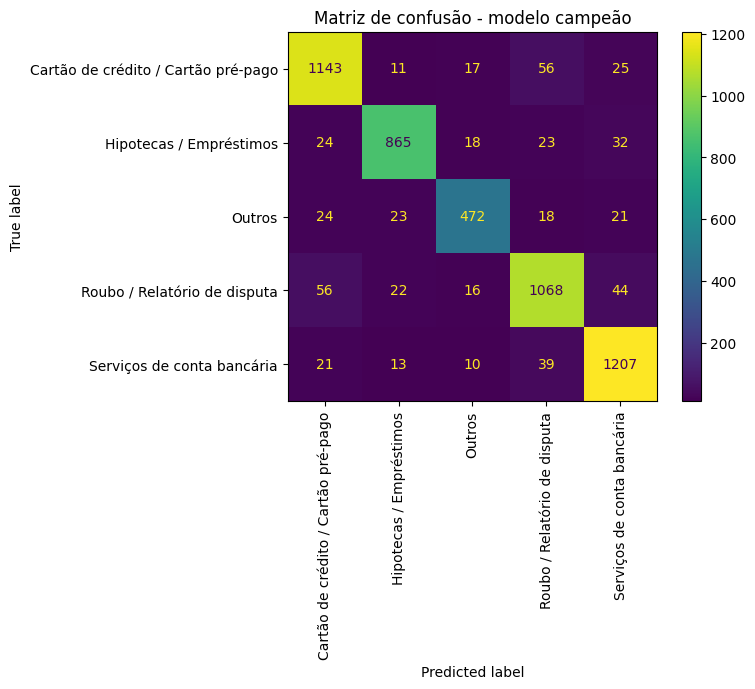

In [ ]:
# ==========================================================
# Visualização rápida do campeão (matriz de confusão)
# ==========================================================
# Use o best_model (grid) como campeão, se ele for o melhor.
y_pred_champ = pred
champ_model = best_model

print("F1 weighted (campeão):", f1_score(y_test, y_pred_champ, average="weighted"))
print(classification_report(y_test, y_pred_champ))

plt.figure(figsize=(10,10))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_champ, xticks_rotation=90)
plt.title("Matriz de confusão - modelo campeão")
plt.show()


### **Sumário do Notebook: Classificador de Chamados da QuantumFinance**

Este notebook tem como objetivo criar um classificador de chamados para a **QuantumFinance**, utilizando técnicas de Processamento de Linguagem Natural (PLN). O trabalho foi dividido em diversas etapas, desde o carregamento dos dados até a seleção e avaliação do modelo campeão.

#### **1. Carregamento e Visão Inicial dos Dados**

*   **Carregamento**: Os dados foram carregados de um arquivo CSV utilizando `pandas.read_csv()`, especificando o delimitador `;`. O dataset contém `id_reclamacao`, `data_abertura`, `categoria` e `descricao_reclamacao`.
*   **Análise Inicial (`df.info()` e `df.head()`)**: Verificou-se o tipo de dados de cada coluna e a presença de valores nulos. A coluna `descricao_reclamacao` foi identificada como o texto a ser classificado (`text_col`) e `categoria` como o rótulo (`label_col`).

#### **2. Entendimento da Base (EDA Rápida)**

*   **Shape e Amostra**: Foram verificadas as dimensões do dataset (`df.shape`) e exibidas algumas amostras para uma compreensão inicial dos dados.
*   **Identificação de Colunas**: Utilizou-se uma heurística para inferir as colunas de texto (`descricao_reclamacao`) e de rótulo (`categoria`).
*   **Valores Nulos**: A contagem de valores nulos nas colunas de interesse (`descricao_reclamacao`, `categoria`) confirmou a ausência de nulos, simplificando o pré-processamento.
*   **Distribuição das Classes**: Analisou-se a distribuição das categorias dos chamados (`df[label_col].value_counts()`) e foi plotado um gráfico de barras para visualizar a frequência das 20 principais classes. Isso ajudou a entender o equilíbrio ou desequilíbrio das classes.
*   **Tamanho dos Textos**: A distribuição do tamanho dos textos (`descricao_reclamacao`) foi analisada através de estatísticas descritivas (`.describe()`) e um histograma, revelando a extensão típica das reclamações.

#### **3. Pré-processamento do Texto**

*   **Objetivo**: Reduzir ruído e padronizar o texto, mantendo a informação semântica útil para o classificador.
*   **Função `normalize_text`**: Implementada para realizar as seguintes transformações:
    *   `lower()`: Converte todo o texto para minúsculas para reduzir a sparsidade e tratar variações de capitalização.
    *   `strip_accents()`: Remove acentos para tratar variações de palavras (ex: "cartão" vs "cartao").
    *   Remoção de e-mails (`\S+@\S+`), URLs (`http\S+|www\.\S+`), e números (`\d+`): Substitui esses elementos por espaços em branco, pois geralmente não contêm informação relevante para a classificação do assunto.
    *   Remoção de pontuação e símbolos (`[^a-z\s]`): Remove caracteres não alfabéticos, focando apenas nas palavras.
    *   `re.sub(r"\s+", " ").strip()`: Remove múltiplos espaços em branco e espaços em excesso no início/fim da string.
*   **Justificativa**: Para modelos baseados em TF-IDF, a lematização nem sempre é estritamente necessária, pois o TF-IDF com n-gramas pode capturar variações. A normalização aplicada é um bom balanço entre simplificação e retenção de informação.
*   **Exemplo**: Um exemplo do texto original e sua versão normalizada foi apresentado para demonstrar o efeito do pré-processamento.

#### **4. Divisão Treino/Teste e Modelos Iniciais (TF-IDF / n-gramas)**

*   **Divisão dos Dados**: Os dados foram separados em conjuntos de treino (75%) e teste (25%) usando `train_test_split` com `random_state=42` e `stratify=y` (para manter a proporção das classes).
*   **Modelo Baseline (`DummyClassifier`)**: Um classificador `DummyClassifier` (estrategicamente `most_frequent`) foi treinado como linha de base para comparar a performance dos modelos mais complexos. Seu F1-weighted foi de **0.096**.
*   **Pipeline TF-IDF + Multinomial Naive Bayes (`pipe_nb`)**: Uma pipeline foi criada combinando `TfidfVectorizer` (com `preprocessor=normalize_text`, `ngram_range=(1,2)`, `min_df=2`) e `MultinomialNB`. Obteve um F1-weighted de **0.696**.
*   **Pipeline TF-IDF + Regressão Logística (`pipe_lr`)**: Semelhante ao anterior, mas utilizando `LogisticRegression` (`max_iter=2000`, `sublinear_tf=True` no TF-IDF). Obteve um F1-weighted de **0.882**.
*   **Pipeline TF-IDF + LinearSVC (`pipe_svc`)**: Outra pipeline com `LinearSVC` (um SVM linear, conhecido por sua eficiência em texto) e `sublinear_tf=True`. Obteve um F1-weighted de **0.890**. Este modelo se mostrou o melhor entre os três primeiros testados.

#### **5. Modelos com Embeddings (Word2Vec)**

*   **Estratégia**: Treinar um modelo `Word2Vec` no corpus de treino para gerar vetores de palavras. Em seguida, representar cada documento pela média dos vetores de suas palavras (Mean Embedding) e treinar um classificador supervisionado sobre esses embeddings.
*   **Tokenização**: Uma função `tokenize` foi definida para dividir o texto normalizado em palavras.
*   **Treinamento Word2Vec**: O modelo `Word2Vec` foi treinado com os `train_tokens`, utilizando parâmetros como `vector_size=200`, `window=5`, `min_count=2`, `sg=1` (skip-gram) e `epochs=20`.
*   **Criação de Embeddings de Documentos**: A função `mean_vector` foi usada para calcular a média dos vetores das palavras de cada documento, resultando em `X_train_w2v` e `X_test_w2v`.
*   **Classificador sobre Embeddings**: Um `LogisticRegression` foi treinado sobre os embeddings, precedido por um `StandardScaler` para normalizar as características. Este modelo obteve um F1-weighted de **0.856**.

#### **6. Otimização com GridSearchCV para o Modelo Campeão**

*   **Seleção para Otimização**: O `LinearSVC` com TF-IDF foi o modelo que apresentou o melhor desempenho até então, sendo escolhido para otimização de hiperparâmetros.
*   **GridSearchCV**: Utilizou-se `GridSearchCV` para buscar a melhor combinação dos hiperparâmetros `tfidf__ngram_range` (`(1,1)` e `(1,2)`) e `clf__C` (`0.5`, `1`, `2`). A métrica de avaliação foi `f1_weighted` com `cv=5`.
*   **Resultados da Otimização**: O `GridSearchCV` encontrou os melhores parâmetros como `clf__C=0.5` e `tfidf__ngram_range=(1,1)`. Este modelo otimizado (`TFIDF_LinearSVC_Grid`) alcançou um F1-weighted de **0.902**.

#### **7. Seleção do Modelo Campeão e Avaliação Final**

*   **Comparativo de Scores**: Todos os F1-weighted scores dos modelos testados foram comparados, confirmando que o `TFIDF_LinearSVC_Grid` (o modelo otimizado via GridSearchCV) obteve a melhor performance no conjunto de teste.
*   **Avaliação do Campeão**: O modelo campeão foi avaliado detalhadamente com:
    *   `classification_report`: Exibiu precisão, recall e F1-score para cada classe, além das médias macro e weighted.
    *   `ConfusionMatrixDisplay`: Plotou a matriz de confusão para visualizar o desempenho do classificador em identificar corretamente cada categoria e onde ocorreram os erros.